In [2]:
from spin_lattices import KagomeLattice
from spin_systems import spin_system, heisenberg, no_symmetries_basis
from ising_sign_reconstruction import reconstruct_signs
import numpy as np
import numpy.typing as npt
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix, diags
from parity import calculate_fourier_transform_matrix
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


In [3]:
system = spin_system(heisenberg(KagomeLattice(2, 4), J2=1), no_symmetries_basis())

In [28]:
config = {"sign_reconstruction.extension_steps": 1}
external_field_coeff = 2
hadamard_amplitude_power = 1
n_iterations = 100

sample_size = 100
hadamard_external_field_iterations = 20

delta_out = []
for amplitude_noise in [0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8]:
    out = []

    hamiltonian = system.hamiltonian

    for iteration in tqdm(range(n_iterations)):
        states = np.sort(
            np.random.choice(
                system.basis.states,
                p=system.ground_state**2,
                size=sample_size,
                replace=False,
            )
        )
        matrix, nbd_states = hamiltonian.to_partial_csr(states)

        extension_states: npt.NDArray[np.uint64] = states
        extension_states_nbd: npt.NDArray[np.uint64] = nbd_states  # type: ignore

        for _ in range(config["sign_reconstruction.extension_steps"]):
            extension_states: npt.NDArray[np.uint64] = extension_states_nbd
            matrix, extension_states_nbd = hamiltonian.to_partial_csr(
                extension_states
            )  # type: ignore

        matrix = matrix[:, np.searchsorted(extension_states_nbd, extension_states)]
        assert np.abs(matrix - matrix.transpose()).max() < 1e-10

        graph_matrix = (matrix != 0).astype(np.int8)
        _, labels = connected_components(graph_matrix, directed=False)
        unique_labels, counts = np.unique(labels, return_counts=True)

        component = unique_labels[np.argmax(counts)]
        component_mask = labels == component
        cluster = extension_states[component_mask]

        matrix_block = matrix[np.ix_(component_mask, component_mask)]

        cluster_ground_state_coeffs = system.get_ground_state_coeffs(
            cluster, apply_symmetries=False
        )
        cluster_amplitudes = np.abs(cluster_ground_state_coeffs) * np.exp(
            np.random.uniform(-amplitude_noise, amplitude_noise, cluster.shape[0])
        )

        cluster_nbd: npt.NDArray[np.uint64]
        extended_matrix, cluster_nbd = hamiltonian.to_partial_csr(cluster)  # type: ignore
        cluster_border = np.setdiff1d(cluster_nbd, cluster, assume_unique=True)
        cluster_border_ground_state = system.get_ground_state_coeffs(
            cluster_border, apply_symmetries=False
        )
        cluster_border_amplitudes = np.abs(cluster_border_ground_state) * np.exp(
            np.random.uniform(
                -amplitude_noise, amplitude_noise, cluster_border.shape[0]
            )
        )

        external_field_matrix = (
            diags(cluster_amplitudes)
            @ extended_matrix[:, np.searchsorted(cluster_nbd, cluster_border)]
            @ diags(cluster_border_amplitudes)
        )

        external_field = np.zeros(cluster.shape[0])
        prev_relsigns = None
        for hadamard_external_field_iteration in range(
            hadamard_external_field_iterations
        ):
            relsigns = reconstruct_signs(
                predicted_amplitudes=cluster_amplitudes,
                hamiltonian_matrix=matrix_block,
                how="greedy_solve",
                field=external_field * external_field_coeff,
            )
            out.append(
                {
                    "iteration": iteration,
                    "external_field_coeff": external_field_coeff,
                    "hadamard_amplitude_power": hadamard_amplitude_power,
                    "cluster_size": cluster.shape[0],
                    "external_field": external_field,
                    "hadamard_external_field_iteration": hadamard_external_field_iteration,
                    "sign_overlap": np.abs(
                        (
                            relsigns
                            * np.sign(cluster_ground_state_coeffs)
                            * cluster_amplitudes**2
                        ).sum()
                        / (cluster_amplitudes**2).sum()
                    ),
                    "sign_accuracy": (
                        (lambda x: max(x, 1 - x))(
                            (relsigns == np.sign(cluster_ground_state_coeffs)).mean()
                        )
                    ),
                }
                | (
                    {
                        "prev_relsigns_overlap": (
                            (relsigns * prev_relsigns * cluster_amplitudes**2).sum()
                            / (cluster_amplitudes**2).sum()
                        ),
                        "prev_relsigns_accuracy": (relsigns == prev_relsigns).mean(),
                        "cluster_border_sign_predictions_overlap": (
                            np.abs(
                                (
                                    sign_predictions
                                    * np.sign(cluster_border_ground_state)
                                    * cluster_border_amplitudes**2
                                ).sum()
                                / (cluster_border_amplitudes**2).sum()
                            )
                        ),
                        "cluster_border_sign_predictions_accuracy": (
                            (lambda x: max(x, 1 - x))(
                                (
                                    sign_predictions
                                    == np.sign(cluster_border_ground_state)
                                ).mean()
                            )
                        ),
                    }
                    if prev_relsigns is not None
                    else {}
                )
            )
            prev_relsigns = relsigns
            if (
                hadamard_external_field_iteration
                != hadamard_external_field_iterations - 1
            ):
                transform_matrix = calculate_fourier_transform_matrix(
                    cluster_border, cluster, out_dtype="float64"
                )
                sign_predictions = np.sign(
                    transform_matrix
                    @ (relsigns * (cluster_amplitudes**hadamard_amplitude_power))
                )
                external_field = external_field_matrix @ sign_predictions
    df = pd.DataFrame(out)

    sign_overlap_delta = (
        df.groupby("iteration")["sign_overlap"]
        .agg(["first", "last"])
        .assign(delta=lambda x: x["last"] - x["first"])
    ).rename(columns={"first": "before", "last": "after"})
    delta_out.append(
        sign_overlap_delta.reset_index().assign(amplitude_noise=amplitude_noise)
    )

  0%|          | 0/100 [00:00<?, ?it/s]

2024-07-29 18:01:40.293 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:01:40.296 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:01:40.297 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:01:40.354 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:01:40.361 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:01:40.362 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:01:40.414 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:01:40.421 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:01:40.422 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using

  0%|          | 0/100 [00:00<?, ?it/s]

2024-07-29 18:03:26.869 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:03:26.871 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:03:26.872 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:03:26.921 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:03:26.923 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:03:26.925 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:03:26.979 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:03:26.981 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:03:26.982 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using

  0%|          | 0/100 [00:00<?, ?it/s]

...

2024-07-29 18:10:42.476 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:10:42.480 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:10:42.481 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:10:42.541 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:10:42.543 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:10:42.544 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:10:42.604 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:10:42.607 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:10:42.610 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using

  0%|          | 0/100 [00:00<?, ?it/s]

2024-07-29 18:12:37.682 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:12:37.683 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:12:37.684 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:12:37.711 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:12:37.713 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:12:37.714 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:12:37.742 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:12:37.744 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:12:37.744 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using

  0%|          | 0/100 [00:00<?, ?it/s]

2024-07-29 18:14:35.377 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:14:35.379 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:14:35.380 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:14:35.454 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:14:35.462 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:14:35.463 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using greedy solve
2024-07-29 18:14:35.534 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-07-29 18:14:35.540 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:41 - Creating ising Hamiltonian
2024-07-29 18:14:35.541 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:60 - Using

In [31]:
df_noise = pd.concat(delta_out, axis=0).reset_index(drop=True)

<Axes: xlabel='amplitude_noise'>

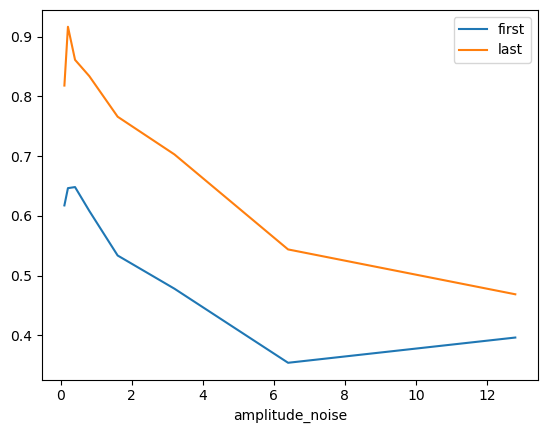

In [20]:
df_noise.groupby("amplitude_noise")[["first", "last"]].mean().plot()

In [32]:
df_noise

,iteration,before,after,delta,amplitude_noise
0,0,0.382912,0.981915,0.599003,0.1
1,1,0.408217,0.992208,0.583990,0.1
2,2,0.967634,0.978553,0.010919,0.1
3,3,0.420426,0.591896,0.171471,0.1
4,4,0.150424,0.615905,0.465481,0.1
...,...,...,...,...,...
795,95,0.070159,0.052170,-0.017989,12.8
796,96,0.000491,0.097894,0.097403,12.8
797,97,0.663881,0.850245,0.186363,12.8
798,98,0.550766,0.407558,-0.143208,12.8


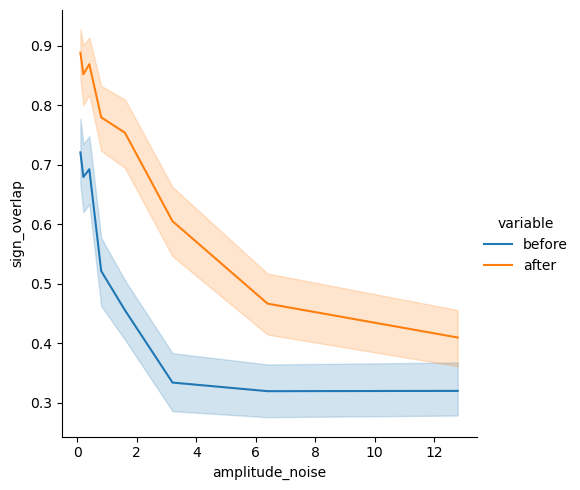

In [33]:
sns.relplot(
    df_noise.melt(id_vars=["amplitude_noise"], value_vars=["before", "after"], value_name="sign_overlap"),
    x="amplitude_noise",
    y="sign_overlap",
    kind="line",
    hue="variable"
)

In [34]:
amplitude_noise_to_overlap = []
for amplitude_noise in [0.1, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8]:
    amplitudes = np.abs(system.ground_state)
    noisy_amplitudes = amplitudes * np.exp(
        np.random.uniform(-amplitude_noise, amplitude_noise, amplitudes.shape[0])
    )
    amplitude_overlap = (
        amplitudes
        @ noisy_amplitudes
        / np.linalg.norm(amplitudes)
        / np.linalg.norm(noisy_amplitudes)
    )
    amplitude_noise_to_overlap.append(
        {"amplitude_noise": amplitude_noise, "amplitude_overlap": amplitude_overlap}
    )

<Axes: xlabel='amplitude_noise'>

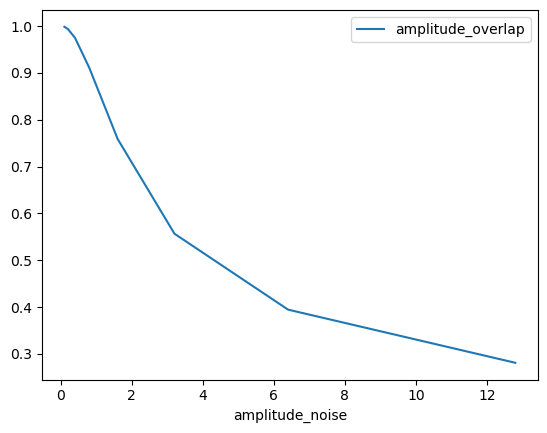

In [35]:
pd.DataFrame(amplitude_noise_to_overlap).plot(x="amplitude_noise", y="amplitude_overlap")

/tmp/nix-shell.0cm8Ru/ipykernel_3072651/37180795.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(


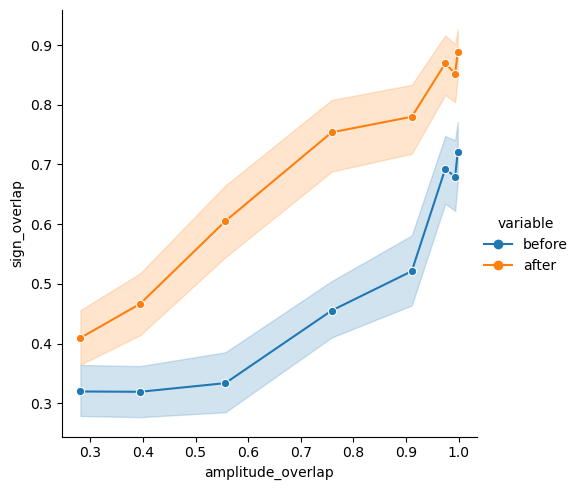

In [39]:
sns.relplot(
    df_noise.merge(
        pd.DataFrame(amplitude_noise_to_overlap),
        on="amplitude_noise",
    ).melt(
        id_vars=["amplitude_noise", "amplitude_overlap"],
        value_vars=["before", "after"],
        value_name="sign_overlap",
    ),
    x="amplitude_overlap",
    y="sign_overlap",
    kind="line",
    style="variable",
    markers=['o'],
    dashes=False,
    hue="variable",
)

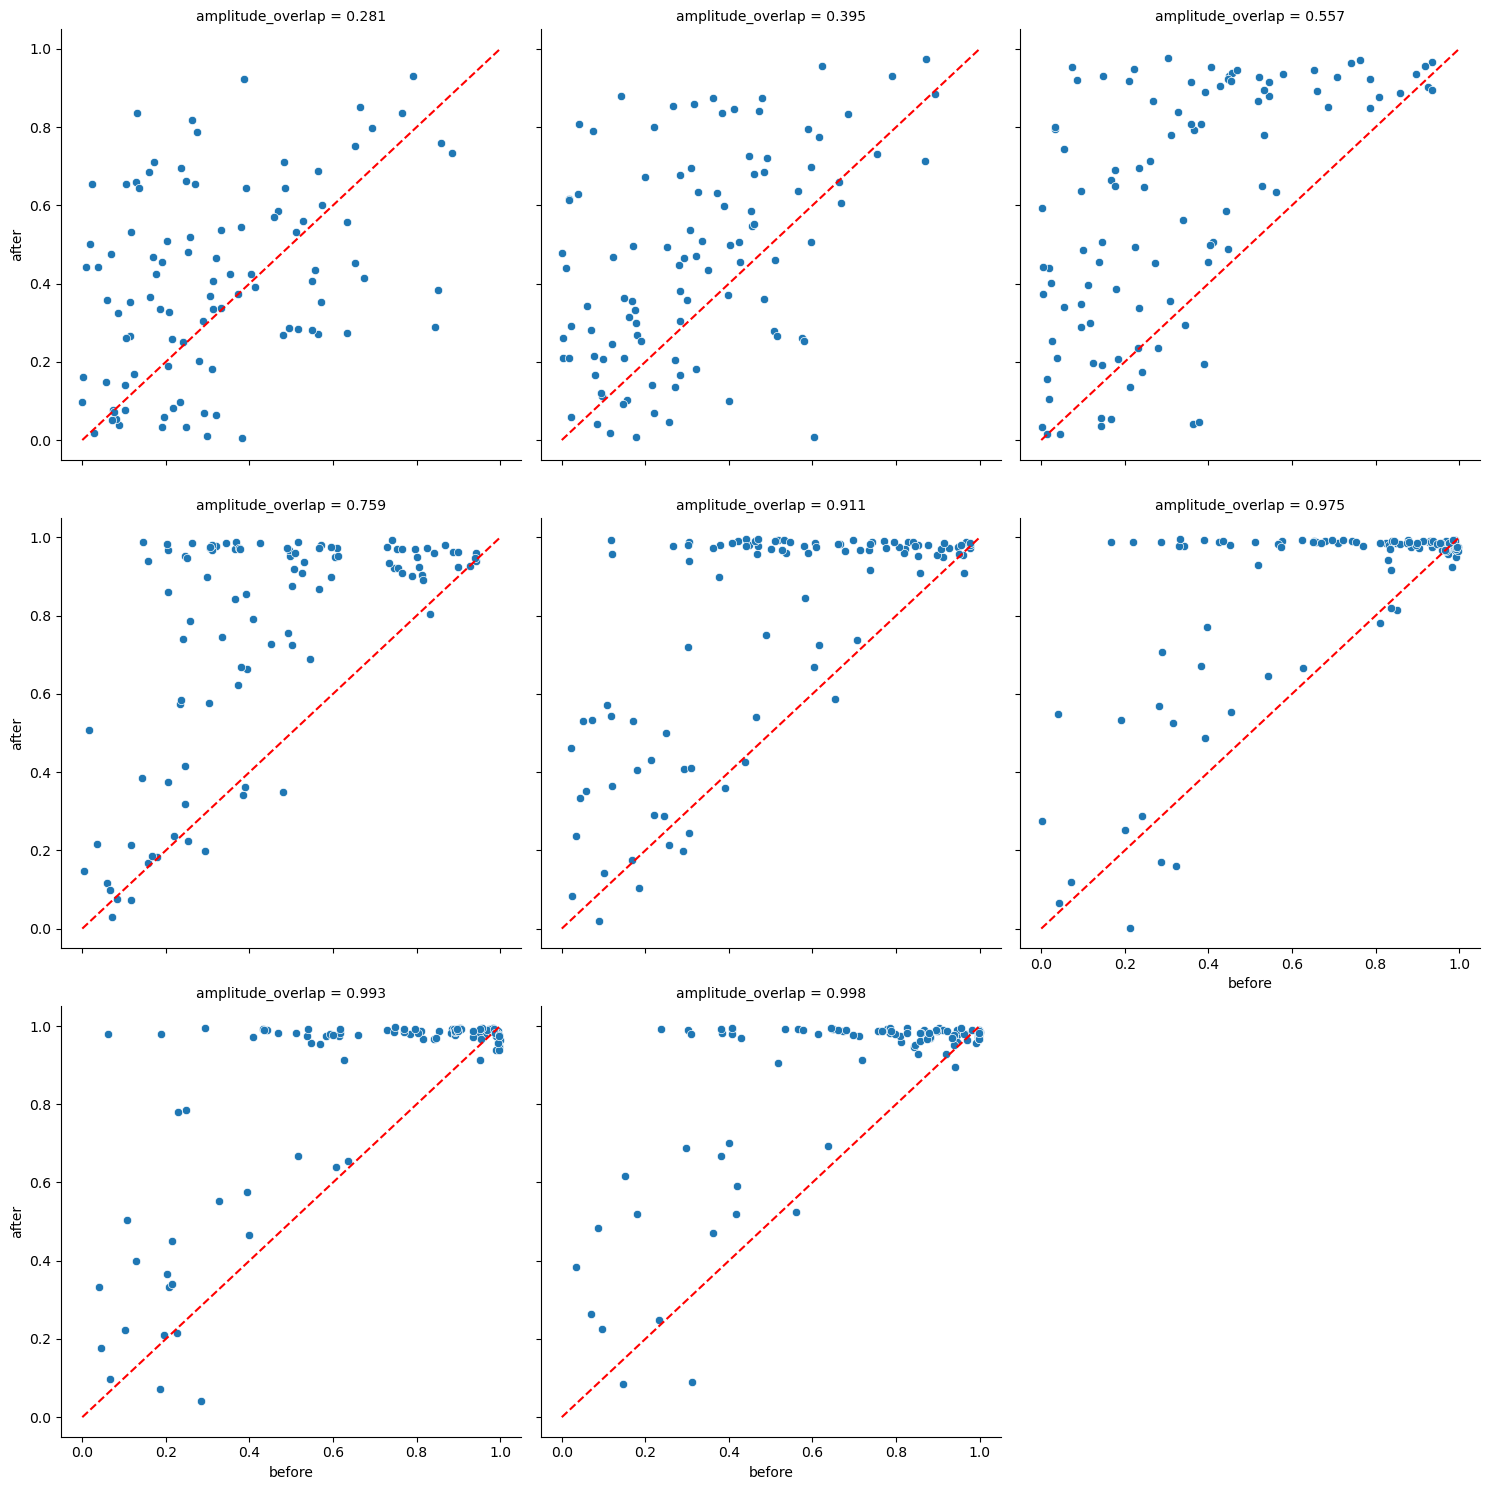

In [49]:
import seaborn as sns

import matplotlib.pyplot as plt

g = sns.relplot(
    data=df_noise.merge(
        pd.DataFrame(amplitude_noise_to_overlap),
        on="amplitude_noise",
    ).assign(
        amplitude_overlap=lambda x: x["amplitude_overlap"].round(3)
    ),
    col="amplitude_overlap",
    col_wrap=3,
    x="before",
    y="after",
    kind="scatter"
)

# Add diagonal line to each panel
for ax in g.axes:
    ax.plot([0, 1], [0, 1], color='red', linestyle='--')



<Axes: xlabel='amplitude_noise'>

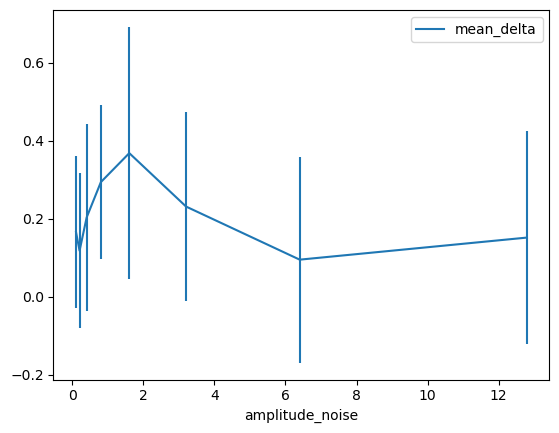

: 

In [5]:
pd.DataFrame(delta_out).plot(x='amplitude_noise', y='mean_delta', yerr='std_delta')

In [25]:
df = pd.DataFrame(out)

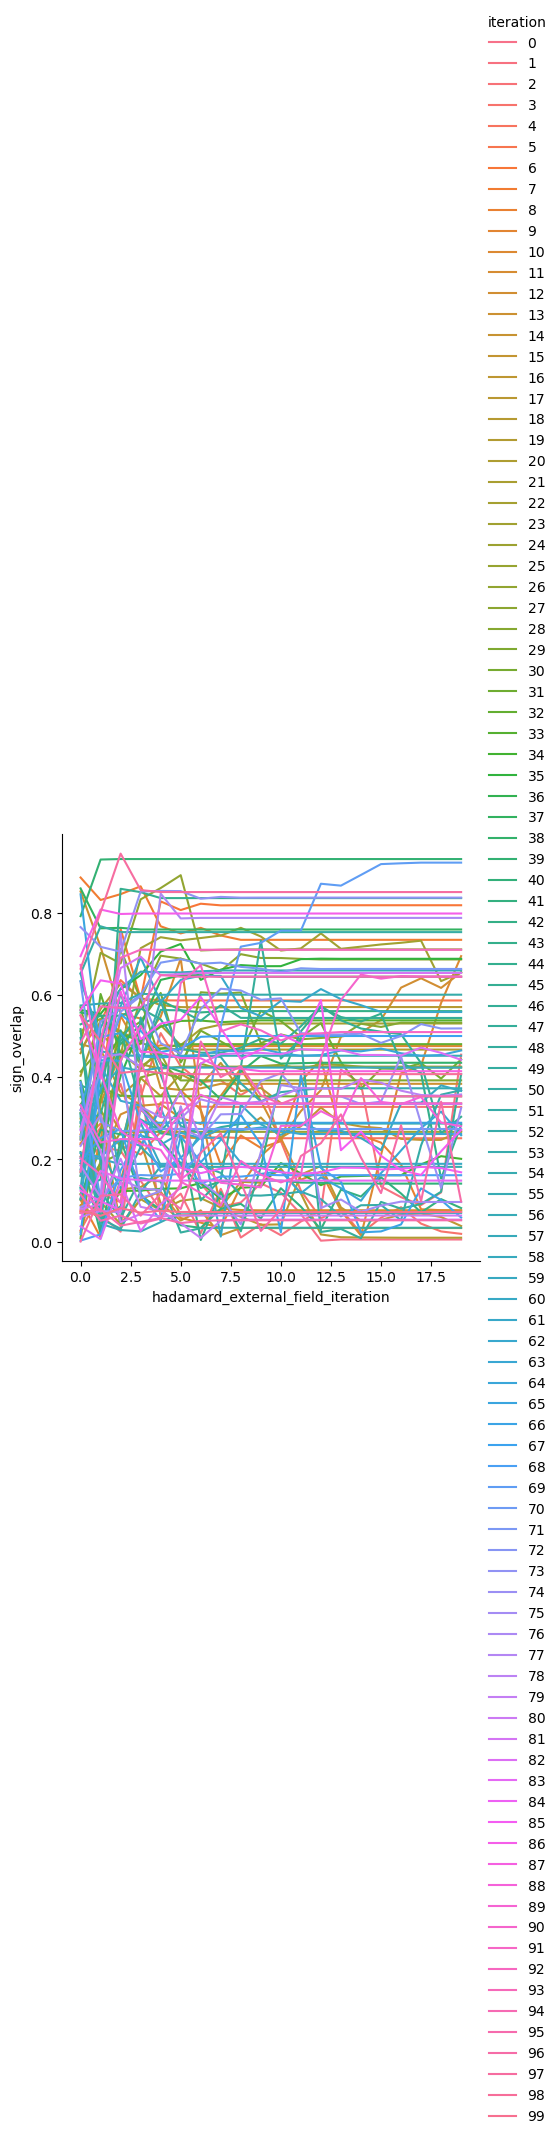

In [40]:
df = pd.DataFrame(out)
sns.relplot(
    df.astype({'iteration': 'category'}),
    x="hadamard_external_field_iteration",
    y="sign_overlap",
    hue="iteration",
    kind='line',
)

In [27]:
sign_overlap_delta = (
    df.groupby("iteration")["sign_overlap"].last()
    - df.groupby("iteration")["sign_overlap"].first()
)

In [31]:
(sign_overlap_delta > 0).mean()

0.75

In [41]:
df.groupby("iteration").last().assign(
    sign_overlap_delta=sign_overlap_delta
).plot.scatter(x="cluster_size", y="sign_overlap_delta")

ValueError: Cannot set a DataFrame with multiple columns to the single column sign_overlap_delta

Text(0.5, 0, 'Initial sign overlap')

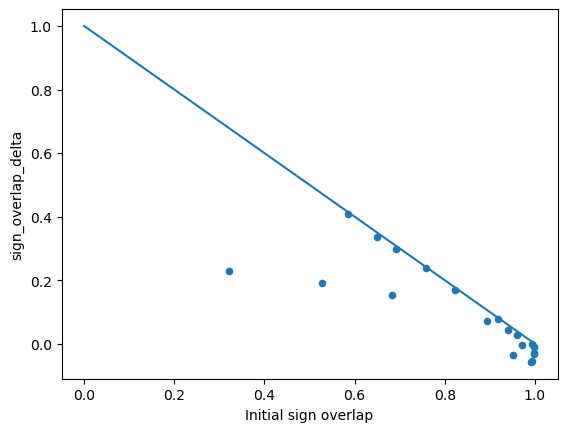

In [106]:
df.groupby("iteration").first().assign(
    sign_overlap_delta=sign_overlap_delta
).plot.scatter(x="sign_overlap", y="sign_overlap_delta")
plt.plot([1, 0], [0, 1])
plt.xlabel("Initial sign overlap")